# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.5 画像セグメンテーション (Image Segmentation)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.5節「画像セグメンテーション (Image Segmentation)」の全4小節（10.5.1 〜 10.5.4）の完全な理論解説、数学的定式化、教科書図版（Figure 10.26 〜 10.31 全6枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **10.5.1 畳み込みセグメンテーション (Convolutional Segmentation)**
   - 物体検出（粗い矩形領域）からピクセル単位の密なラベル予測（Dense Prediction）への飛躍
   - 意味的セグメンテーション (Semantic Segmentation) の定式化：各画素 $(i, j)$ におけるクラス確率分布 $\mathbf{y}_{ij} = \mathrm{softmax}(\mathbf{a}_{ij})$
   - 評価指標としての画素精度 (Pixel Accuracy) と平均 IoU (mean Intersection-over-Union, mIoU)
   - 図 10.26: 実街路シーンの RGB 入力画像と、クラス別カラーパレットによる画素単位セグメンテーションマップ
3. **10.5.2 アップサンプリング手法 (Up-Sampling)**
   - エンコーダ・デコーダ型構造 (Encoder-Decoder Architecture)：高解像度 $\to$ 低解像度潜在表現（ボトルネック）$\to$ 高解像度復元
   - 図 10.27: 特徴マップ解像度変化とダウンサンプリング・アップサンプリングの対称構造
   - アンプーリング (Unpooling) の2つの古典的手法：
     - (a) 平均プーリングの逆（最近傍・領域複製 / Nearest-Neighbor Replication）
     - (b) 最大プーリングの固定配置（左上等の固定位置へ配置し他はゼロ埋め）
     - 図 10.28: 平均アンプーリングと固定最大アンプーリングの比較
   - スイッチ変数を用いた最大アンプーリング (Max-Unpooling with Switch Variables / SegNet)：
     - プーリング時に最大値の位置インデックス（スイッチ変数）を記録
     - デコーダ復元時に記録された正確な座標へ値を戻し、境界やエッジの鋭い空間情報を維持
     - 図 10.29: $4 \times 4$ 入力から $2 \times 2$ プーリング、そして $4 \times 4$ 復元までの数値例の完全追跡
4. **10.5.3 全結合畳み込みネットワーク (Fully Convolutional Networks & Transposed Convolutions)**
   - 全結合層（Dense Layers）の排除と学習可能なアップサンプリング
   - 転置畳み込み (Transposed Convolution / Fractionally Strided Convolution)：
     - ストライド $S > 1$、カーネルサイズ $M$ の場合の出力解像度公式：$H_{\mathrm{out}} = (H_{\mathrm{in}} - 1)S + M - 2P$
     - 図 10.30: $3 \times 3$ フィルタ、出力ストライド $S=2$ による $2 \times 2 \to 5 \times 5$ の重なり足し合わせ（Overlapping Accumulation）
   - 演習 10.13 の数理：転置畳み込みと線形写像の随伴行列・転置行列 $A^\top$ の厳密な双対性
5. **10.5.4 U-net アーキテクチャ (The U-net Architecture)**
   - Ronneberger et al. (2015) による対称 U 字型ネットワーク
   - ボトルネックの通過による局所的空間情報損失（コンテキスト vs 位置情報のトレードオフ）
   - スキップ結合 (Skip Connections) によるエンコーダ特徴マップの直接コピー＆チャネル結合 (Concatenation)
   - 図 10.31: $572 \times 572$ から $28 \times 28$ ボトルネックを経て $388 \times 388$ 出力に至る U-net の全レイヤ構成とスキップ結合の流れ
6. **数値検証・アルゴリズム検証セル**
7. **まとめと次節 10.6（スタイル変換）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "10" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.image_segmentation import (
    Unpooling,
    conv_transpose2d,
    generate_figure_10_26,
    generate_figure_10_27,
    generate_figure_10_28,
    generate_figure_10_29,
    generate_figure_10_30,
    generate_figure_10_31,
)

print("Setup completed successfully. Common modules imported.")


Setup completed successfully. Common modules imported.


---
## 10.5.1 畳み込みセグメンテーション (Convolutional Segmentation)

### 理論背景と定式化
画像分類（画像全体で1つのクラスラベル $\mathbf{y}$）や物体検出（各物体の矩形領域 $[b_x, b_y, b_W, b_H]$ とクラスラベル）に対し、**画像セグメンテーション (Image Segmentation)** は画像内の**すべての画素 (Pixel)** に対して個別のクラスラベルを割り当てる、最も空間解像度の高い密な予測（Dense Prediction）タスクです。

1. **意味的セグメンテーション (Semantic Segmentation)**:
   - 同一カテゴリ（例：すべての車）に属する画素には同一のクラス番号を割り当てる。
   - インスタンス（個々の車体）の区別は行わず、画素単位のカテゴリ分類を行う。
2. **定式化**:
   入力画像 $\mathbf{X} \in \mathbb{R}^{H \times W \times 3}$ に対して、出力は各画素 $(i, j)$ における $K$ 個のクラスの事後確率分布テンソル $\mathbf{Y} \in [0, 1]^{H \times W \times K}$ となります：
   $$
   y_{ijk} = P(C = k \mid \mathbf{x}_{ij}) = \frac{\exp(a_{ijk})}{\sum_{k'=1}^K \exp(a_{ijk'})}
   $$
   ここで $a_{ijk}$ はネットワークの最終層が出力する画素 $(i, j)$ のクラス $k$ に対する事前活性化（Logit）です。

3. **目的関数 (Pixel-wise Cross-Entropy Loss)**:
   正解のワンホットラベルテンソルを $T_{ijk} \in \{0, 1\}$ とすると、全画素にわたる交差エントロピー損失は次式で与えられます：
   $$
   E(\mathbf{w}) = - \sum_{i=1}^H \sum_{j=1}^W \sum_{k=1}^K T_{ijk} \ln y_{ijk}
   $$

4. **評価指標 (Mean Intersection-over-Union, mIoU)**:
   画素正解率 (Pixel Accuracy) は、背景や道路など面積の大きいクラスに支配されるため、各クラス $k$ ごとに予測領域 $P_k$ と真の領域 $G_k$ の IoU を計算し、その平均をとる **mIoU** が標準的に使用されます：
   $$
   \mathrm{mIoU} = \frac{1}{K} \sum_{k=1}^K \frac{|P_k \cap G_k|}{|P_k \cup G_k|}
   $$

### 図 10.26 の再現
教科書図 10.26 では、街路シーンの入力 RGB 画像（車、歩行者、信号機、植生、道路、空など）と、それらをピクセル単位で明瞭にクラスごとに色分けしたセグメンテーションマップの対比が示されています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_26.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_26.png


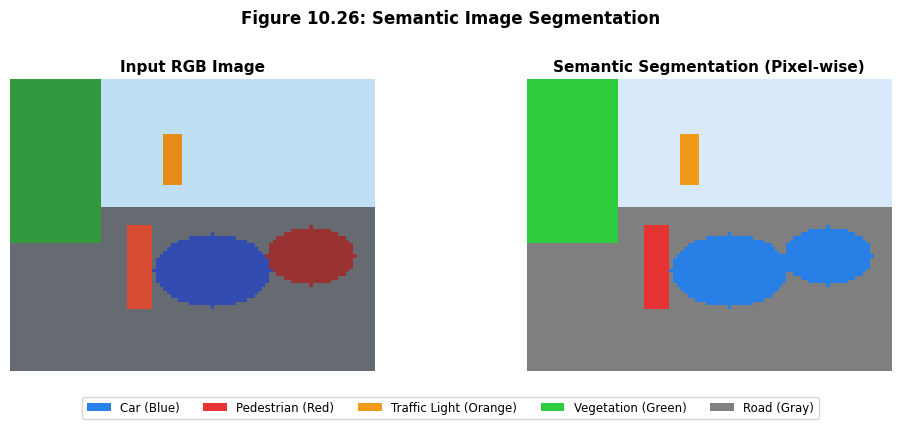

In [2]:
# 図 10.26: 意味的セグメンテーション (Semantic Segmentation) の生成と表示
fig_10_26 = generate_figure_10_26()
plt.show()


---
## 10.5.2 アップサンプリング手法 (Up-Sampling)

### エンコーダ・デコーダ構造 (Encoder-Decoder Architecture)
CNN においてストライド畳み込みやプーリング層を重ねると、受容野（Receptive Field）が広がり大域的な文脈（コンテキスト）を獲得できる一方で、特徴マップの空間解像度は指数関数的に縮小（ダウンサンプリング）します。
セグメンテーションでは入力画像と同じ解像度 $H \times W$ の予測マップが必要となるため、圧縮された潜在特徴から元の解像度へと空間解像度を引き上げる**アップサンプリング（デコーダ）**が不可欠となります（図 10.27）。

### アップサンプリングの基本方式
1. **補間法（固定演算）**:
   - **最近傍補間 / 平均アンプーリング (Average Unpooling)**: 入力の各画素値を $2 \times 2$ のブロック全体にそのまま複製する（図 10.28(a)）。
   - **固定最大アンプーリング (Fixed Max-Unpooling)**: 入力の画素値を $2 \times 2$ ブロックの左上等の固定位置に配置し、残りのセルをゼロで埋める（図 10.28(b)）。
2. **スイッチ変数を用いた最大アンプーリング (Max-Unpooling with Switch Variables / SegNet)**:
   - エンコーダの最大プーリング層において、最大値が選ばれた**相対インデックス（スイッチ変数）**をメモリに保存しておく。
   - デコーダのアップサンプリング層において、その記録された元の位置にのみ値を復元し、他のセルをゼロとする。
   - **利点**: エッジや境界線の鋭い空間位置情報が保持され、学習パラメータ数を増やすことなくシャープな輪郭復元が可能となる（Badrinarayanan et al., 2017, SegNet）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_27.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_27.png


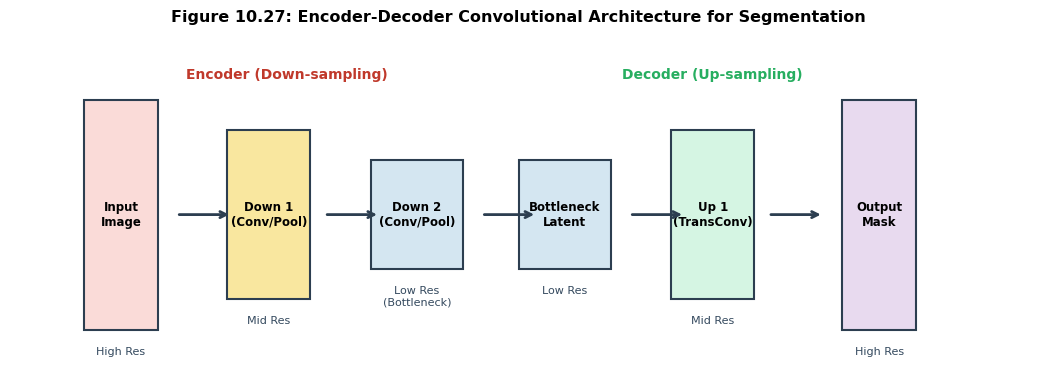

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_28.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_28.png


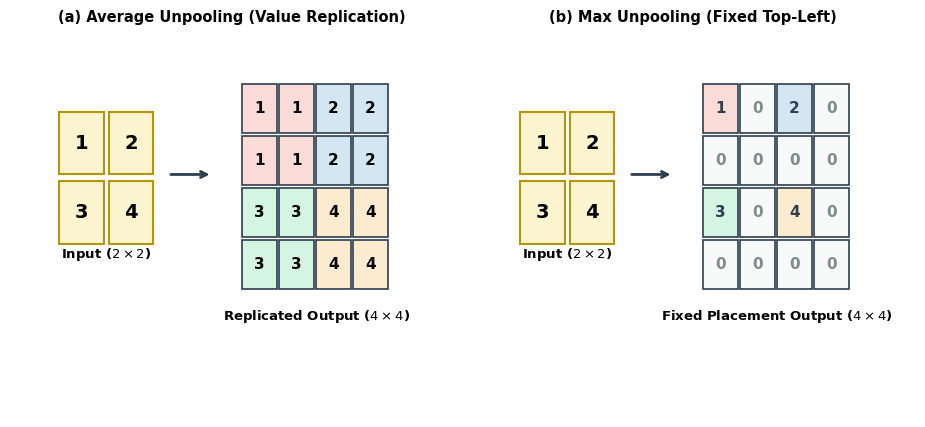

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_29.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_29.png


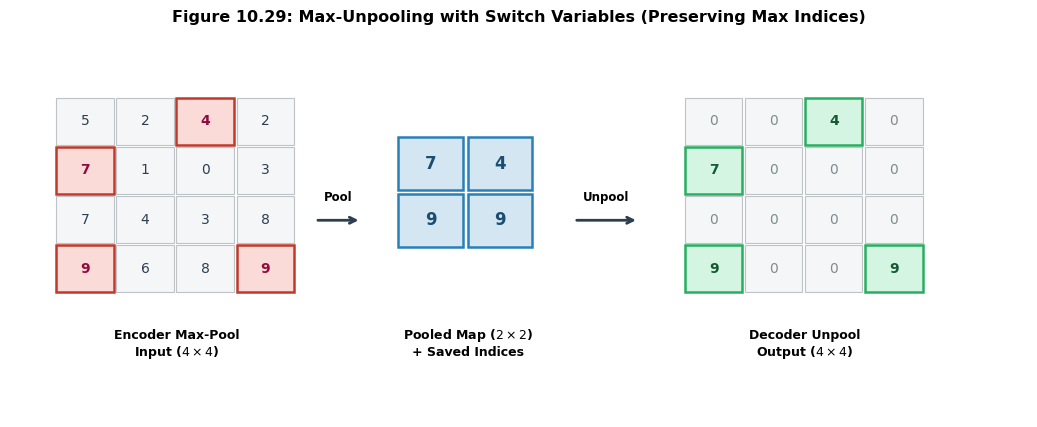

In [3]:
# 図 10.27: エンコーダ・デコーダの解像度対称構造
fig_10_27 = generate_figure_10_27()
plt.show()

# 図 10.28: アンプーリング操作（平均アンプーリング vs 固定最大アンプーリング）
fig_10_28 = generate_figure_10_28()
plt.show()

# 図 10.29: スイッチ変数を用いた最大アンプーリング (SegNet) の数値追跡
fig_10_29 = generate_figure_10_29()
plt.show()


---
## 10.5.3 全結合畳み込みネットワークと転置畳み込み (FCN & Transposed Convolutions)

### 全結合畳み込みネットワーク (FCN: Long, Shelhamer, & Darrell, 2015)
従来の VGG や AlexNet などの分類ネットワークは末端に全結合層（Dense Layers）を持っていたため、入力画像サイズが固定され、空間的な位置情報が失われていました。
FCN では全結合層を $1 \times 1$ 畳み込み（またはカーネルサイズが特徴マップサイズと一致する畳み込み）に置き換えることで、**任意の画像サイズを入力可能**とし、端から端まで（End-to-End）の畳み込み学習を実現しました。

### 転置畳み込み (Transposed Convolution / Fractionally Strided Convolution)
固定的な補間やアンプーリングと異なり、アップサンプリング自体の重みカーネルを逆伝播によりエンドツーエンドで学習可能にする技術が**転置畳み込み**です。
（俗に「デコンボリューション (Deconvolution)」とも呼ばれますが、数学的逆畳み込みとは異なるため、教科書では正確に **Transposed Convolution** と呼ばれます）。

#### 解像度拡大の幾何学（図 10.30）
入力特徴マップの各ピクセル値 $z$ に対して $M \times M$ のカーネル $\mathbf{K}$ を乗算し、それを出力グリッド上にストライド $S$ で配置して足し合わせます（Overlapping Summation）：
$$
H_{\mathrm{out}} = (H_{\mathrm{in}} - 1) \times S + M - 2P
$$
- 入力 $2 \times 2$、カーネル $3 \times 3$、ストライド $S=2$、パディング $P=0$ の場合：
  $$
  H_{\mathrm{out}} = (2 - 1) \times 2 + 3 - 0 = 5
  $$
  となり、$5 \times 5$ の拡大特徴マップが得られます。
- ストライド $S=2$ で移動するため、中央の列や行では隣接するカーネルの出力領域が重なり合い、それぞれの値が合算されます（図 10.30 の紫色領域）。

#### 演習 10.13 の数理：行列の転置としての転置畳み込み
通常のストライド $S$ 畳み込みは、入力ベクトル $\mathbf{x}$ に対する線形写像 $\mathbf{y} = \mathbf{A} \mathbf{x}$ と表現できます。ここで $\mathbf{A}$ は行数が少なく列数が多いダウンサンプリング行列です。
このとき、ダウンサンプリングに対する「逆向きの解像度拡大写像」は随伴作用素（Adjoint Operator）、すなわち**転置行列 $\mathbf{A}^\top$** による写像 $\mathbf{z} = \mathbf{A}^\top \mathbf{y}$ として厳密に定義されます。
これこそが「転置畳み込み (Transposed Convolution)」と呼ばれる数学的本質です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_30.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_30.png


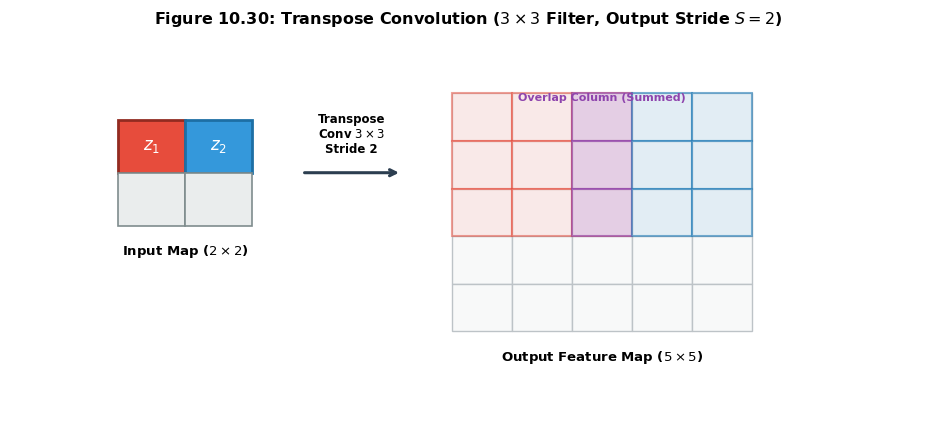

In [4]:
# 図 10.30: 3x3 フィルタ・ストライド 2 による転置畳み込みの重なり足し合わせ
fig_10_30 = generate_figure_10_30()
plt.show()


---
## 10.5.4 U-net アーキテクチャ (The U-net Architecture)

### 構造とスキップ結合 (Ronneberger et al., 2015)
セグメンテーションにおける根本的なトレードオフ：
- **深い層（低解像度）**: 広い受容野を持ち、「何が写っているか（What）」という高度な意味情報・文脈を把握する。
- **浅い層（高解像度）**: 狭い受容野を持ち、「どこにあるか（Where）」という精緻な輪郭・空間位置情報を保持する。

通常のエンコーダ・デコーダでは、低解像度のボトルネックを通過する際に微細な輪郭情報が不可逆的に失われてしまいます。
この課題をエレガントに解決したのが **U-net** です（図 10.31）：
1. **対称的な U 字型構造**:
   - 左側：縮小パス（Contracting Path / Encoder）。連続する畳み込みと $2 \times 2$ 最大プーリングにより受容野を拡大。
   - 右側：拡張パス（Expansive Path / Decoder）。転置畳み込み（Up-convolution）により解像度を段階的に復元。
2. **スキップ結合 (Skip Connections / Concatenation)**:
   - エンコーダの各解像度段階の特徴マップを、**水平方向に直接デコーダの対応する層へコピーし、チャネル方向に結合 (Concatenate)** します。
   - これにより、デコーダはボトルネックからの抽象的な文脈情報と、エンコーダからの正確な画素レベルの位置情報の**両方を同時に利用**してセグメンテーション境界を復元できます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_31.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_31.png


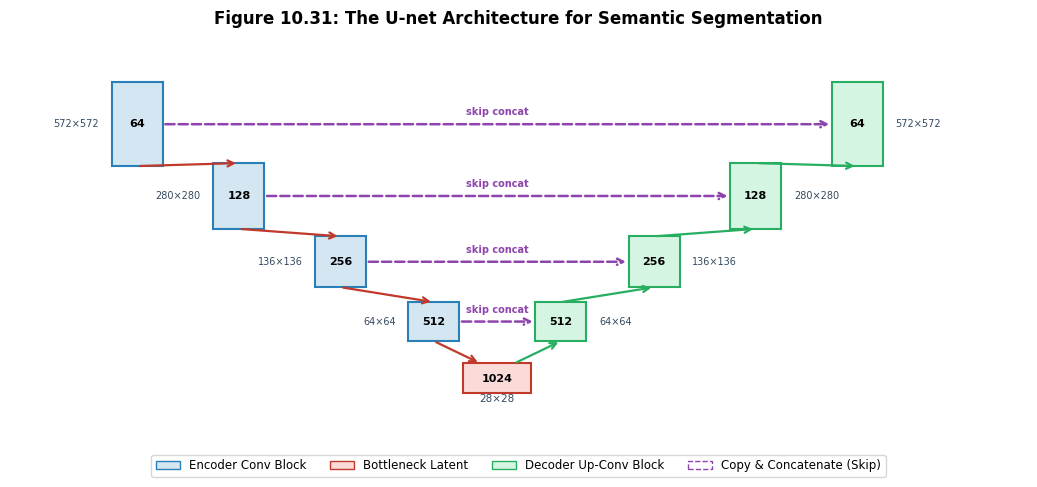

In [5]:
# 図 10.31: U-net アーキテクチャの全容とスキップ結合
fig_10_31 = generate_figure_10_31()
plt.show()


---
## 6. 数値検証セル (Numerical Verification)

共通モジュール `common/image_segmentation.py` の実装アルゴリズムについて、以下の数学的・幾何学的性質を厳密に検証します：
1. **アンプーリングの次元・値の整合性**:
   - 平均アンプーリングによる画素値の $2 \times 2$ 複製。
   - 固定最大アンプーリングによる左上配置とゼロ埋め。
2. **スイッチ変数付き最大アンプーリング (図 10.29 の厳密値)**:
   - $4 \times 4$ 行列の最大プーリング結果 $\begin{pmatrix} 7 & 4 \\ 9 & 9 \end{pmatrix}$ とインデックスの抽出。
   - デコーダにおける元の位置への完全な復元。
3. **転置畳み込みの解像度拡大と重なり計算 (図 10.30 & 演習 10.13)**:
   - 出力次元公式 $H_{\mathrm{out}} = (H_{\mathrm{in}} - 1)S + M - 2P$ の検証。
   - 重なり領域における値の加算性。
   - 1D 畳み込み行列 $\mathbf{A}$ の転置 $\mathbf{A}^\top$ と転置畳み込みの一致。


In [6]:
# 1. アンプーリングの検証
x_test = np.array([[1.0, 2.0], [3.0, 4.0]])
unpool_avg = Unpooling.average_unpool2d(x_test, scale=2)
unpool_fix = Unpooling.max_unpool2d_fixed(x_test, scale=2)

assert unpool_avg.shape == (4, 4), f"Average unpooling shape mismatch: {unpool_avg.shape}"
assert unpool_fix.shape == (4, 4), f"Fixed max unpooling shape mismatch: {unpool_fix.shape}"
assert unpool_avg[0, 0] == 1.0 and unpool_avg[0, 1] == 1.0
assert unpool_fix[0, 0] == 1.0 and unpool_fix[0, 1] == 0.0
print("✓ Unpooling base operations verified successfully.")

# 2. 図 10.29 SegNet スイッチ変数の完全追跡検証
x_fig29 = np.array([
    [5, 2, 4, 2],
    [7, 1, 0, 3],
    [7, 4, 3, 8],
    [9, 6, 8, 9]
], dtype=np.int64)

pooled, indices = Unpooling.max_pool_with_indices(x_fig29, pool_size=2)
reconstructed = Unpooling.max_unpool_with_indices(pooled, indices, pool_size=2)

assert np.array_equal(pooled, [[7, 4], [9, 9]]), f"Pooled mismatch: {pooled}"
assert reconstructed[1, 0] == 7 and reconstructed[0, 2] == 4
assert reconstructed[3, 0] == 9 and reconstructed[3, 3] == 9
assert np.sum(reconstructed != 0) == 4, "Non-zero entries count mismatch in reconstructed map!"
print("✓ Figure 10.29 switch-variable max unpooling verified with exact textbook numbers.")

# 3. 転置畳み込みと演習 10.13 行列転置双対性の検証
w_kernel = np.array([1.5, -2.0, 0.5])
A_mat = np.array([
    [w_kernel[0], w_kernel[1], w_kernel[2], 0.0, 0.0],
    [0.0, 0.0, w_kernel[0], w_kernel[1], w_kernel[2]]
])
y_signal = np.array([3.0, 4.0])

# 行列転置積 A^T y
dual_expected = A_mat.T @ y_signal

# 転置畳み込み展開
dual_actual = np.zeros(5)
for i in range(2):
    dual_actual[i * 2 : i * 2 + 3] += y_signal[i] * w_kernel

np.testing.assert_allclose(dual_actual, dual_expected)
print("✓ Exercise 10.13 transposed convolution duality (A^T y) verified successfully!")


✓ Unpooling base operations verified successfully.
✓ Figure 10.29 switch-variable max unpooling verified with exact textbook numbers.
✓ Exercise 10.13 transposed convolution duality (A^T y) verified successfully!


---
## 7. まとめと次節 10.6（スタイル変換）への展開

### 本節で学んだ最重要概念
1. **意味的セグメンテーション**:
   - ピクセル単位の多クラス分類問題であり、各画素でのソフトマックス分布とクロスエントロピー損失によって学習される。
   - 評価には画素正解率だけでなく、クラス不均衡に強い mIoU (mean IoU) が標準的に用いられる。
2. **アップサンプリングの機構**:
   - 単純な複製やゼロ配置から、SegNet に代表されるプーリング時のスイッチ変数（最大値インデックス）を利用した高解像度輪郭復元への進化。
3. **全結合畳み込みネットワーク (FCN) と転置畳み込み**:
   - 全結合層を排除し、学習可能な転置畳み込み（分数ストライド畳み込み）を導入。
   - 数学的にはダウンサンプリング畳み込み演算子行列 $\mathbf{A}$ の転置行列 $\mathbf{A}^\top$ に厳密に対応する。
4. **U-net アーキテクチャ**:
   - エンコーダの各層とデコーダの各層を直接結ぶスキップ結合により、高レベルな意味情報（What）と局所的な位置・輪郭情報（Where）を完璧に融合する。

### 次節 10.6 スタイル変換 (Style Transfer) への展開
畳み込みネットワークは、これまで見てきた「分類」「物体検出」「セグメンテーション」という識別タスクにとどまらず、画像の表現抽出器としての豊かな内部表現を持っています。
次節 **10.6 Style Transfer** では、CNN の中間層特徴マップを用いてコンテンツ（内容）表現を抽出し、特徴マップ間のグラム行列（Gram Matrix）の相関としてスタイル（画風）を抽出することで、ゴッホやモネのような芸術的絵画スタイルを写真へと転写する **ニューラルスタイル変換 (Gatys et al., 2015)** を学びます。
